Processed data file not found. Processing gradients...


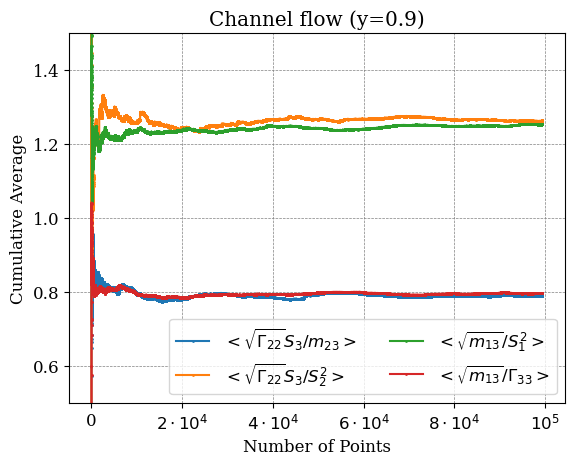

In [3]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-channel-09-from-file.npy')
        print("Loaded existing processed data from 'AtA-channel-09-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-09.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((4, len(S1)), dtype=np.float32)
    inv[0, :] = np.sqrt(g22) * S3/ m23
    inv[1, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[2, :] = np.sqrt(m13) / (S1**2)
    inv[3, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-channel-09-from-file-y-axis.npy', inv)

process_from_file()

InvLoad=np.load('AtA-channel-09-from-file-y-axis.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Channel flow (y=0.9)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=2)

# Setting the y-axis limits
plt.ylim(bottom=0.5, top=1.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray')

# Customizing the x-axis ticks
custom_xticks = [0, 20000, 40000, 60000, 80000, 100000]  # Custom tick positions
custom_xticklabels = ['0','$2\cdot 10^4$', '$4\cdot 10^4$', '$6\cdot 10^4$', '$8\cdot 10^4$', '$10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-09-y-axis.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Processed data file not found. Processing gradients...


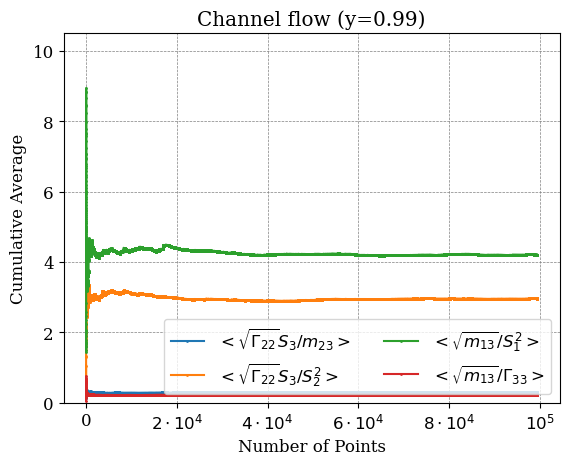

In [9]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-channel-099-from-file.npy')
        print("Loaded existing processed data from 'AtA-channel-099-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-099.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((4, len(S1)), dtype=np.float32)
    inv[0, :] = np.sqrt(g22) * S3/ m23
    inv[1, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[2, :] = np.sqrt(m13) / (S1**2)
    inv[3, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-channel-099-from-file-y-axis.npy', inv)

process_from_file()

InvLoad=np.load('AtA-channel-099-from-file-y-axis.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Channel flow (y=0.99)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=2)

# Setting the y-axis limits
plt.ylim(bottom=0, top=10.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray')

# Customizing the x-axis ticks
custom_xticks = [0, 20000, 40000, 60000, 80000, 100000]  # Custom tick positions
custom_xticklabels = ['0','$2\cdot 10^4$', '$4\cdot 10^4$', '$6\cdot 10^4$', '$8\cdot 10^4$', '$10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-099-y-axis.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

Processed data file not found. Processing gradients...


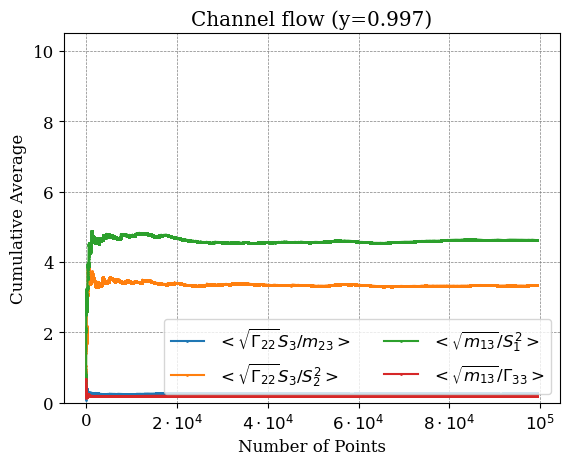

In [8]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
#plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"

def process_from_file():
    # Check if the processed file already exists
    try:
        InvLoad = np.load('AtA-channel-0997-from-file.npy')
        print("Loaded existing processed data from 'AtA-channel-0997-from-file.npy'")
        return InvLoad
    except FileNotFoundError:
        print("Processed data file not found. Processing gradients...")

    grads = np.load('gradients-0997.npy')

    # Check dimensions of grads
    if grads.ndim != 4:
        raise ValueError("grads array must be 4-dimensional")

    # Calculate invariants
    Gamma = np.matmul(grads, np.transpose(grads, (0, 1, 3, 2)))
     
    # Compute eigenvalues of each matrix in Gamma
    eigenvalues = np.linalg.eigvals(Gamma)
    
    # Check if all eigenvalues are positive
    positive_definite_indices = np.all(eigenvalues > 0, axis=-1)
    Gamma = Gamma[positive_definite_indices]

    # Calculate s1, s2, s3 with additional checks
    s1 = np.sqrt(np.maximum(Gamma[:, 0, 0], 0))
    s2 = np.sqrt(np.maximum(Gamma[:, 0, 0] * Gamma[:, 1, 1] - Gamma[:, 0, 1]**2, 0))
    s3 = np.sqrt(np.maximum(np.linalg.det(Gamma), 0))
    m13 = np.maximum(Gamma[:, 0, 0] * Gamma[:, 2, 2] - Gamma[:, 0, 2]**2, 0)
    m23 = np.maximum(Gamma[:, 1, 1] * Gamma[:, 2, 2] - Gamma[:, 1, 2]**2, 0)
    g22 = np.maximum(Gamma[:, 1, 1], 0)
    g33 = np.maximum(Gamma[:, 2, 2], 0)

    # Combine all exclusion criteria
    non_zero_indices = (s1 > 0) & (s2 > 0) & (s3 > 0) & (m13 > 0) & (m23 > 0)  & (g22 > 0) & (g33 > 0)

    # Apply combined filter to all relevant arrays
    s1 = s1[non_zero_indices]
    s2 = s2[non_zero_indices]
    s3 = s3[non_zero_indices]
    m13 = m13[non_zero_indices]
    m23 = m23[non_zero_indices]
    g22 = g22[non_zero_indices]
    g33 = g33[non_zero_indices]

    # Flatten invariants (не нужно, так как уже одномерные)
    S1 = s1
    S2 = s2
    S3 = s3

    # Calculate invariant ratios
    inv = np.zeros((4, len(S1)), dtype=np.float32)
    inv[0, :] = np.sqrt(g22) * S3/ m23
    inv[1, :] = np.sqrt(g22) * S3/ (S2**2)
    inv[2, :] = np.sqrt(m13) / (S1**2)
    inv[3, :] = np.sqrt(m13) / (g33)

    # Save results
    np.save('AtA-channel-0997-from-file-y-axis.npy', inv)

process_from_file()

InvLoad=np.load('AtA-channel-0997-from-file-y-axis.npy')

# Предполагаем, что InvLoadIso имеет форму (5, NIso)
N = InvLoad.shape[1]

# Вычисляем кумулятивную сумму
cumsum = np.cumsum(InvLoad, axis=1)

# Создаем массив индексов для деления
indices = np.arange(1, N + 1)

# Вычисляем кумулятивное среднее
AverChan = cumsum / indices

# Plotting the values against their indices with smaller markers
plt.plot(indices, AverChan[0], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/m_{23}>$')
plt.plot(indices, AverChan[1], marker='o', markersize=1, label='$<\sqrt{\Gamma_{22}}S_3/S_2^2>$')
plt.plot(indices, AverChan[2], marker='o', markersize=1, label='$<\sqrt{m_{13}}/S_1^2>$')
plt.plot(indices, AverChan[3], marker='o', markersize=1, label='$<\sqrt{m_{13}}/\Gamma_{33}>$')

# Adding title and labels
plt.title('Channel flow (y=0.997)')
plt.xlabel('Number of Points')
plt.ylabel('Cumulative Average')

# Adding a legend inset
plt.legend(loc='lower right', ncol=2)

# Setting the y-axis limits
plt.ylim(bottom=0, top=10.5)  # Adjust 'top' to your desired maximum value


# Customizing the grid
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray')

# Customizing the x-axis ticks
custom_xticks = [0, 20000, 40000, 60000, 80000, 100000]  # Custom tick positions
custom_xticklabels = ['0','$2\cdot 10^4$', '$4\cdot 10^4$', '$6\cdot 10^4$', '$8\cdot 10^4$', '$10^5$']  # Custom tick labels
plt.xticks(custom_xticks, custom_xticklabels)

# Saving the plot as a JPEG file
plt.savefig('grid-0997-y-axis.jpg', format='jpeg', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()